<a href="https://colab.research.google.com/github/HussainHaider/agentic-AI-cohort/blob/main/sesssion3/W3_1_2_Langgraph_tools_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#%pip install -U langgraph langchain_openai langchain_community

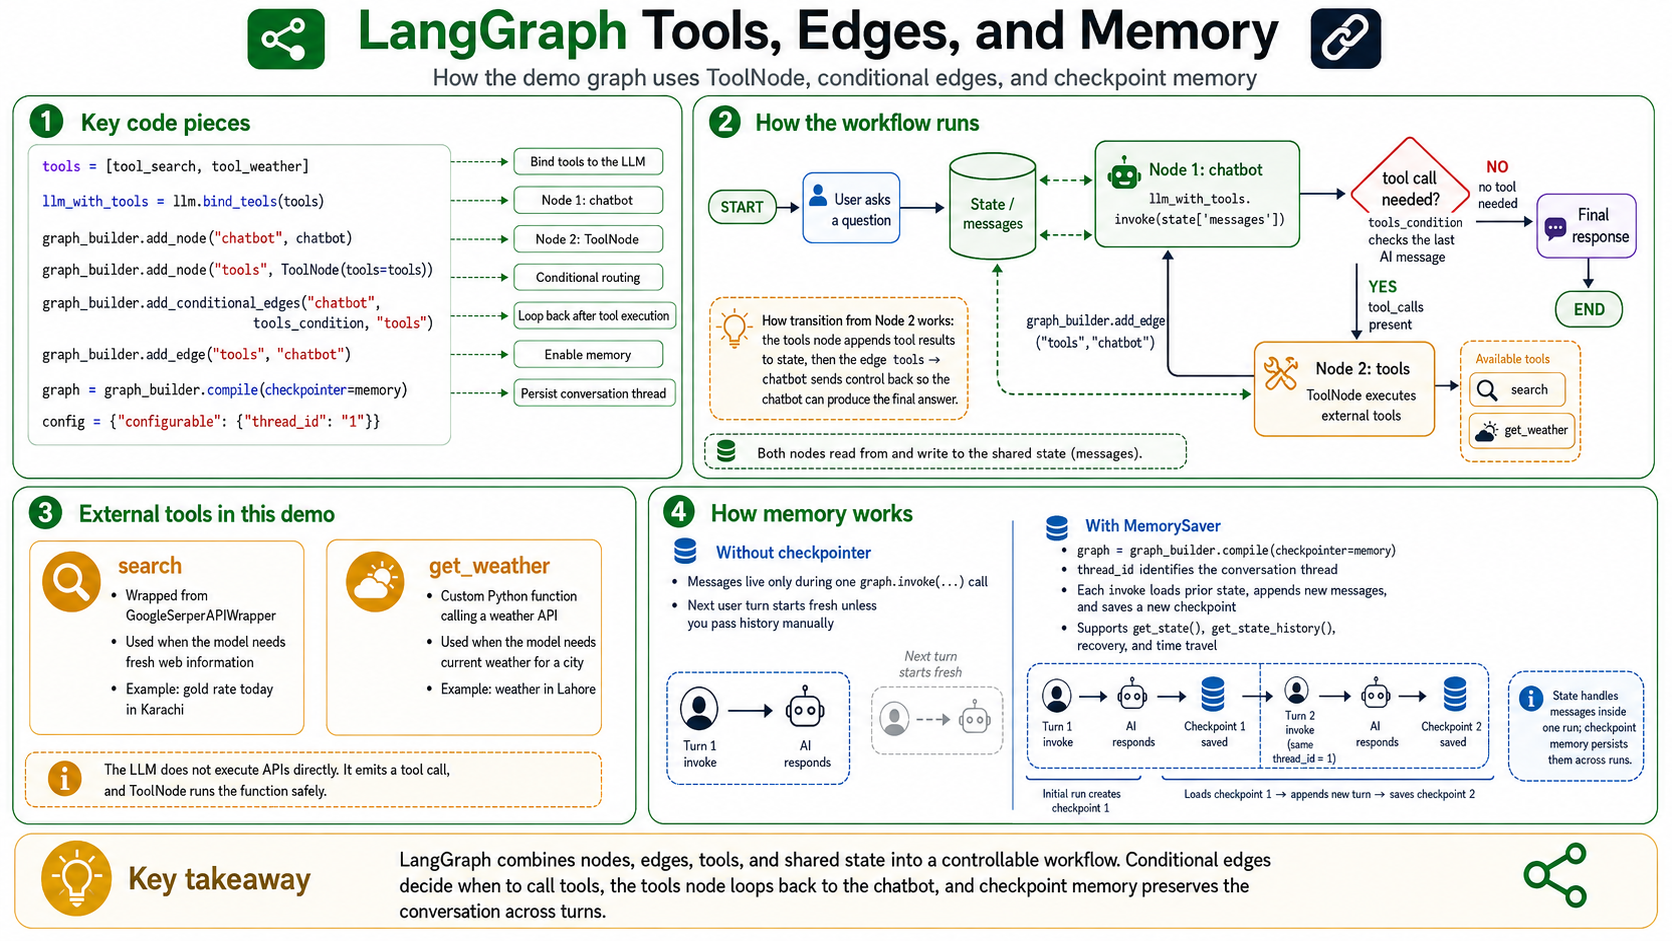

In [ ]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict


### First, let's go set up LangSmith!

https://langsmith.com

In [ ]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "YOUR_LANGCHAIN_API_KEY" # Replace with your LangChain API Key

### Next, here is a useful function in LangChain community:

In [ ]:
from google.colab import userdata
serper = userdata.get('serper_api')

In [ ]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper(serper_api_key = serper)
serper.run("What is current exchange rate $ to pkr?")

'278.14 Pakistani Rupee'

### Now here is a LangChain wrapper class for converting functions into Tools

In [ ]:
# from langchain.agents import Tool

# tool_search =Tool(
#         name="search",
#         func=serper.run,
#         description="Useful for when you need more information from an online search"
#     )

ImportError: cannot import name 'Tool' from 'langchain.agents' (/usr/local/lib/python3.12/dist-packages/langchain/agents/__init__.py)

### Now we can try out the tool the langchain way

In [ ]:
#tool_search.invoke("What is the gold rate today in karachi?")

### And now let's write a tool ourselves

We'll pick a familiar one

In [ ]:
# Weather API from rapidAPI
#https://rapidapi.com/worldapi/api/open-weather13
import requests

url = "https://open-weather13.p.rapidapi.com/city"

querystring = {"city":"Lahore","lang":"EN"}

headers = {
	"x-rapidapi-key": "5cf8fcaf61msh613f010a34f3576p1953e5jsn110a1e6c667d",  # Add your API key here
	"x-rapidapi-host": "open-weather13.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)

print(response.json())

In [ ]:
def get_weather(city: str):
    """Fetches weather information for a given city using RapidAPI."""
    url = "https://open-weather13.p.rapidapi.com/city"
    querystring = {"city": city, "lang": "EN"}
    headers = {
        "x-rapidapi-key": "5cf8fcaf61msh613f010a34f3576p1953e5jsn110a1e6c667d", # Using userdata to store the key
        "x-rapidapi-host": "open-weather13.p.rapidapi.com"
    }
    try:
        response = requests.get(url, headers=headers, params=querystring)
        response.raise_for_status()  # Raise an exception for bad status codes
        return response.json()
    except requests.exceptions.RequestException as e:
        return f"Error fetching weather data: {e}"

In [ ]:
def get_weather(city: str) -> str:
  """Get weather for a given city."""
  url = "https://open-weather13.p.rapidapi.com/city"

  querystring = {"city":city,"lang":"EN"}

  headers = {
    "x-rapidapi-key": key,  # Add your API key here
    "x-rapidapi-host": "open-weather13.p.rapidapi.com"
  }

  response = requests.get(url, headers=headers, params=querystring)

  print(response.json())
  return(response.json())

In [ ]:
# from langchain.agents import Tool

# tool_weather = Tool(
#     name="get_weather",
#     func=get_weather,
#     description="Useful for when you need to get the current weather for a city. Input should be a city name."
# )
# tool_weather.invoke("Lahore")

###
When we implement tools, we always need to make 2 changes to the code:

1. Changes to provide the tools to OpenAI in json when we make the call

2. Changes to handle the results back: look for the model staying that the finish_reason=="tool_calls" and then retrieve the call, run the function, provide the results.

### Bring them together

In [ ]:
tools = [get_weather]

In [ ]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

In [ ]:
from google.colab import userdata
openkey = userdata.get('projsite')

In [ ]:
# This is different:

llm = ChatOpenAI(model="gpt-5-nano", api_key = openkey)
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# Step 3: Create a Node


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

ValueError: Node `chatbot` already present.

In [ ]:
# Step 4: Create Edges


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")

# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")
# graph_builder.add_edge(START, "chatbot")

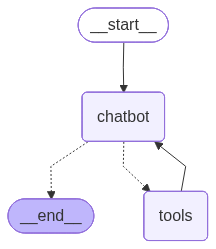

In [ ]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! And, let's do this:

In [ ]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6fc1081078342ab6d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/utils.py", line 882, in async_wrapper
    response = await f(*args, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6fc1081078342ab6d0.gradio.live


## OK it's time to add Memory!

### BUT WAIT!

We have this whole Graph maintaining the state and appending to the state.

Why isn't this handling memory?

### This is a crucial point for understanding LangGraph

> A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.


One "Super-Step" of the graph represents one invocation of passing messages between agents.

In idomatic LangGraph, you call invoke to run your graph for each super-step; for each interaction.

The reducer handles state updates automatically within one super-step, but not between them.

That is what checkpointing achieves.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [ ]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-5-nano", api_key = openkey)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

In [ ]:
graph.get_state(config)

In [ ]:
# Most recent first

list(graph.get_state_history(config))

### LangGraph gives you tools to set the state back to a prior point in time, to branch off:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

And this allows you to build stable systems that can be recovered and rerun from any prior checkpoint.

### And now let's store in SQL

### And this is the power of LangGraph.

In [ ]:
!pip install langgraph-checkpoint-sqlite

In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

In [ ]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-5-nano", api_key = openkey)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()